In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('StressLevelDataset.csv')

In [3]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (1100, 21)
Columns: ['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [5]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [6]:
df.isnull().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

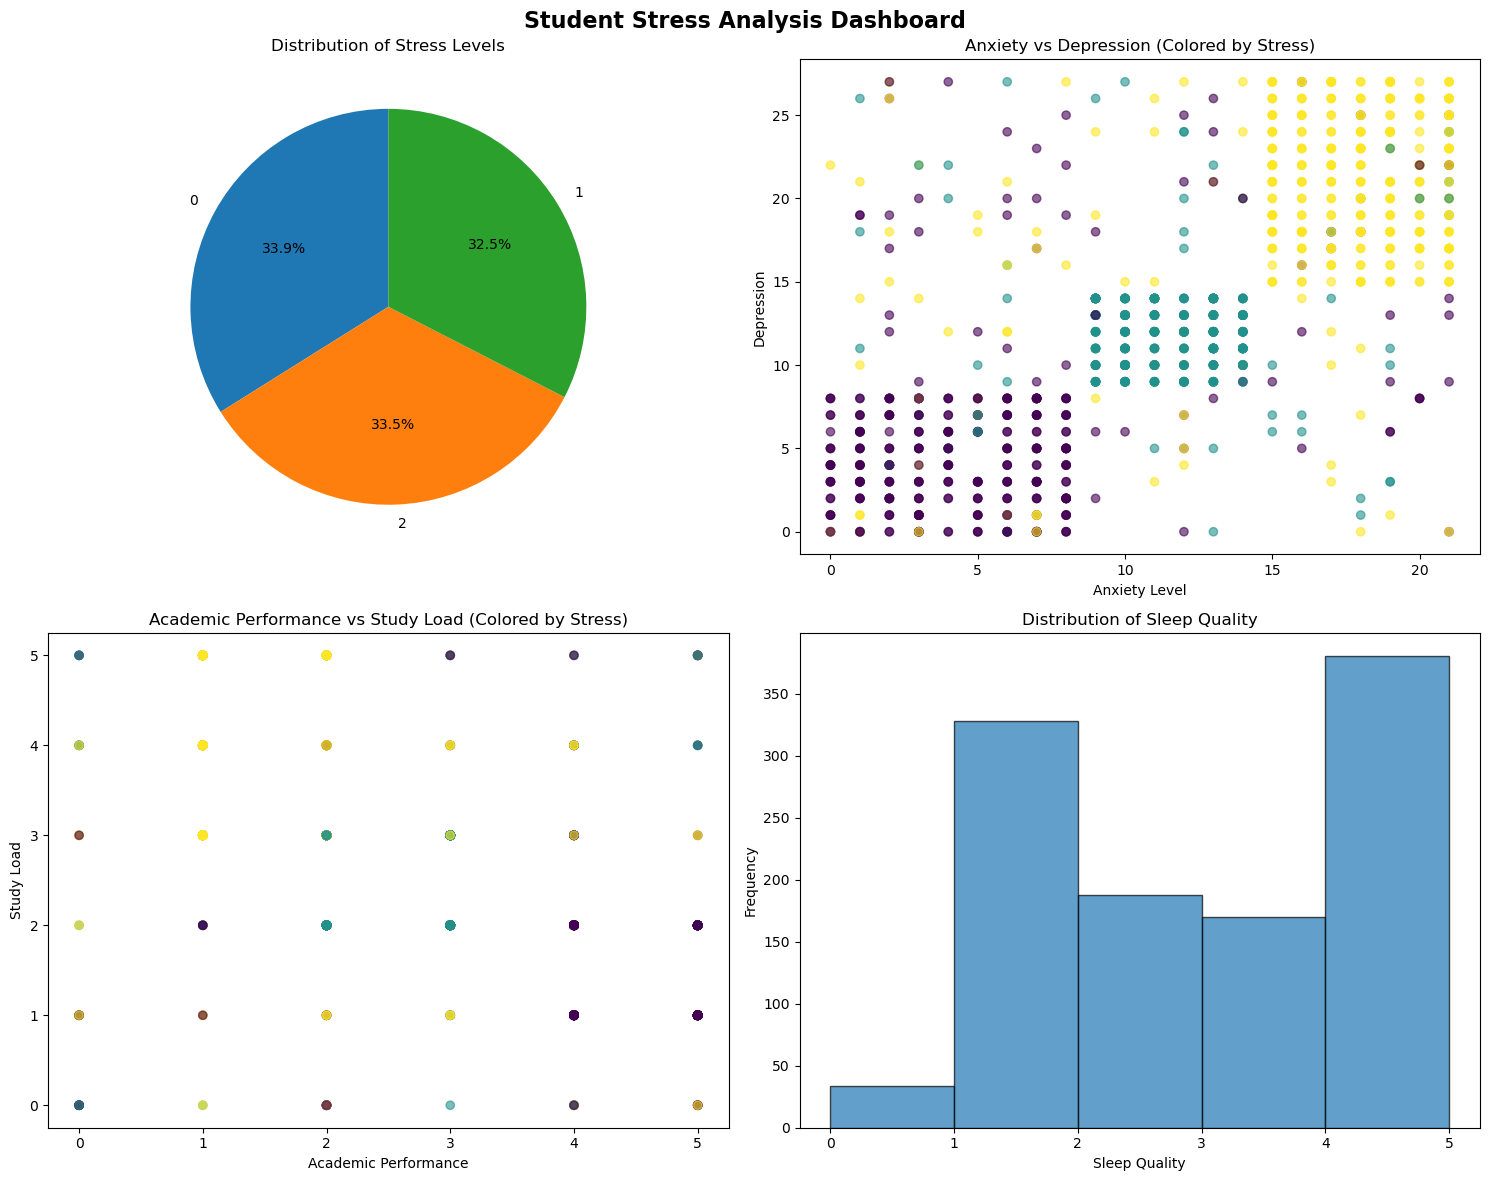

In [7]:
# Create a comprehensive visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Student Stress Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Stress Level Distribution
stress_counts = df['stress_level'].value_counts()
axes[0,0].pie(stress_counts, labels=stress_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribution of Stress Levels')

# 2. Top stress factors by category (if available)
# Let's use anxiety_level vs depression
if 'anxiety_level' in df.columns and 'depression' in df.columns:
    axes[0,1].scatter(df['anxiety_level'], df['depression'], c=df['stress_level'].astype('category').cat.codes, alpha=0.6)
    axes[0,1].set_xlabel('Anxiety Level')
    axes[0,1].set_ylabel('Depression')
    axes[0,1].set_title('Anxiety vs Depression (Colored by Stress)')
else:
    # Fallback to available columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) >= 2:
        axes[0,1].scatter(df[numeric_cols[0]], df[numeric_cols[1]], c=df['stress_level'].astype('category').cat.codes, alpha=0.6)
        axes[0,1].set_xlabel(numeric_cols[0])
        axes[0,1].set_ylabel(numeric_cols[1])
        axes[0,1].set_title(f'{numeric_cols[0]} vs {numeric_cols[1]} (Colored by Stress)')

# 3. Academic Performance vs Study Load (if available)
if 'academic_performance' in df.columns and 'study_load' in df.columns:
    axes[1,0].scatter(df['academic_performance'], df['study_load'], c=df['stress_level'].astype('category').cat.codes, alpha=0.6)
    axes[1,0].set_xlabel('Academic Performance')
    axes[1,0].set_ylabel('Study Load')
    axes[1,0].set_title('Academic Performance vs Study Load (Colored by Stress)')
else:
    # Use any available numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) >= 2:
        axes[1,0].hist(df[numeric_cols[0]], bins=10, alpha=0.7, edgecolor='black')
        axes[1,0].set_xlabel(numeric_cols[0])
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title(f'Distribution of {numeric_cols[0]}')

# 4. Sleep Quality or any available factor
if 'sleep_quality' in df.columns:
    axes[1,1].hist(df['sleep_quality'], bins=5, edgecolor='black', alpha=0.7)
    axes[1,1].set_xlabel('Sleep Quality')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].set_title('Distribution of Sleep Quality')
else:
    # Use the first numeric column available
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        axes[1,1].hist(df[numeric_cols[0]], bins=10, alpha=0.7, edgecolor='black')
        axes[1,1].set_xlabel(numeric_cols[0])
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title(f'Distribution of {numeric_cols[0]}')

plt.tight_layout()
plt.show()

In [8]:
# Correlation Analysis

# Convert categorical stress levels to numerical for correlation
df_corr = df.copy()
stress_mapping = {'low': 0, 'moderate': 1, 'high': 2}
df_corr['stress_level_num'] = df_corr['stress_level'].map(stress_mapping)

correlations = df_corr.corr()['stress_level_num'].sort_values(ascending=False)
print("Top 10 factors most correlated with stress level:")
print(correlations.head(11)[1:])  # Exclude self-correlation

Top 10 factors most correlated with stress level:
self_esteem             NaN
mental_health_history   NaN
depression              NaN
headache                NaN
blood_pressure          NaN
sleep_quality           NaN
breathing_problem       NaN
noise_level             NaN
living_conditions       NaN
safety                  NaN
Name: stress_level_num, dtype: float64


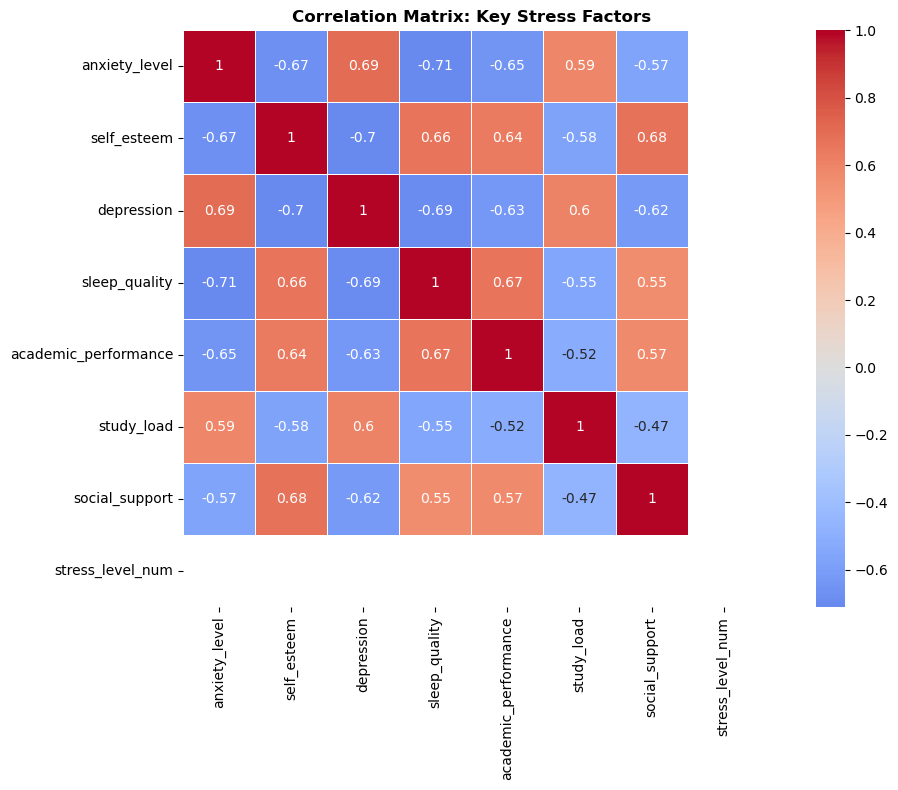

In [9]:
# Heatmap of key stress factors
plt.figure(figsize=(12, 8))
key_factors = ['anxiety_level', 'self_esteem', 'depression', 'sleep_quality', 
               'academic_performance', 'study_load', 'social_support', 'stress_level_num']
correlation_matrix = df_corr[key_factors].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Key Stress Factors', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Analysis by stress categories
categories = {
    'Psychological': ['anxiety_level', 'self_esteem', 'mental_health_history', 'depression'],
    'Physiological': ['headache', 'blood_pressure', 'sleep_quality', 'breathing_problem'],
    'Environmental': ['noise_level', 'living_conditions', 'safety', 'basic_needs'],
    'Academic': ['academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns'],
    'Social': ['social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']
}

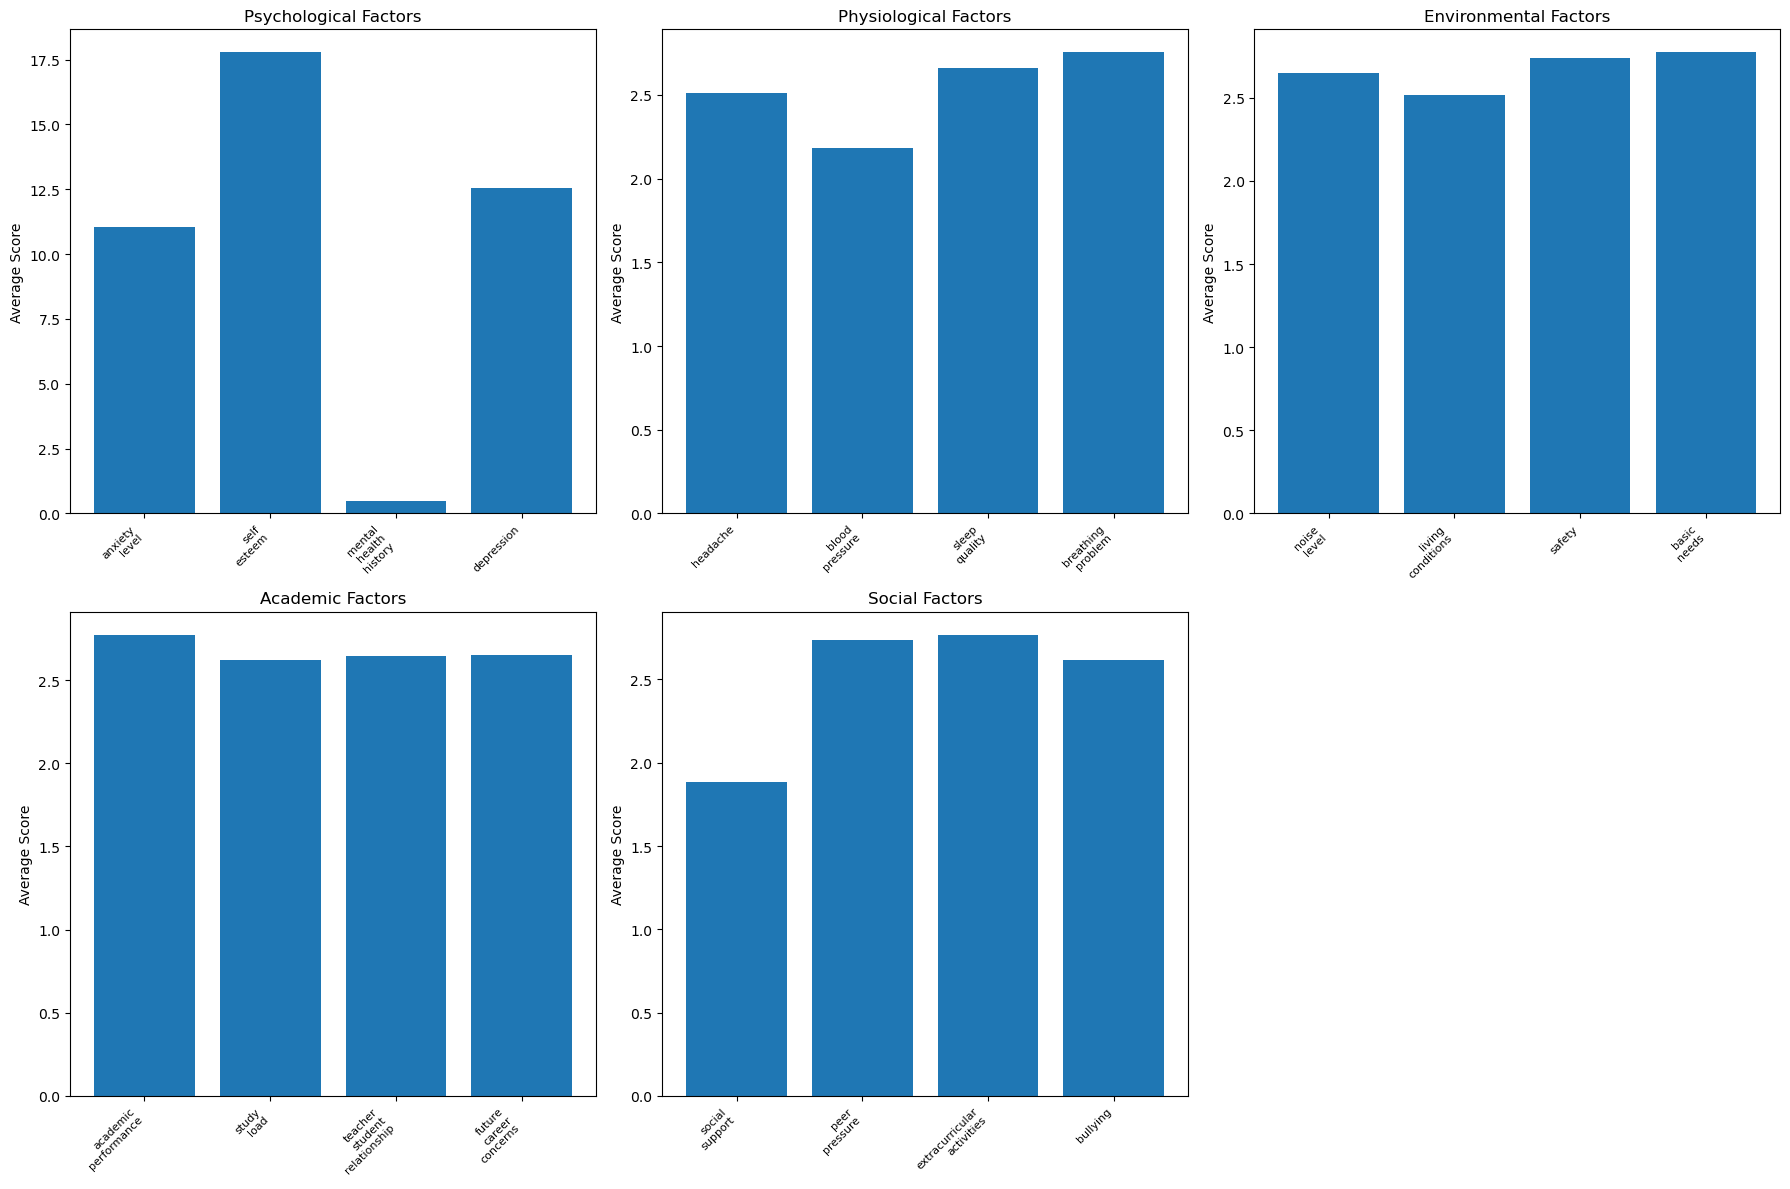

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (category, factors) in enumerate(categories.items()):
    if i < 5:  # We have 5 categories
        category_mean = df[factors].mean()
        axes[i].bar(range(len(category_mean)), category_mean.values)
        axes[i].set_title(f'{category} Factors')
        axes[i].set_xticks(range(len(category_mean)))
        axes[i].set_xticklabels([f.replace('_', '\n') for f in category_mean.index], 
                               rotation=45, ha='right', fontsize=8)
        axes[i].set_ylabel('Average Score')

# Remove the last empty subplot
axes[5].remove()
plt.tight_layout()
plt.show()


In [12]:
# Statistical insights

high_stress = df[df['stress_level'] == 'high']
low_stress = df[df['stress_level'] == 'low']

print(f"1. Students with high stress have {high_stress['anxiety_level'].mean():.2f} average anxiety level")
print(f"   vs {low_stress['anxiety_level'].mean():.2f} for low stress students")

print(f"2. Sleep quality: High stress = {high_stress['sleep_quality'].mean():.2f}, Low stress = {low_stress['sleep_quality'].mean():.2f}")

print(f"3. Academic performance: High stress = {high_stress['academic_performance'].mean():.2f}, Low stress = {low_stress['academic_performance'].mean():.2f}")

1. Students with high stress have nan average anxiety level
   vs nan for low stress students
2. Sleep quality: High stress = nan, Low stress = nan
3. Academic performance: High stress = nan, Low stress = nan


In [13]:
print(df['anxiety_level'])

0       14
1       15
2       12
3       16
4       16
        ..
1095    11
1096     9
1097     4
1098    21
1099    18
Name: anxiety_level, Length: 1100, dtype: int64


In [14]:
X = df.drop(['stress_level'], axis=1)
y = df['stress_level']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=132, stratify=y)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print("Training machine learning models...")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training machine learning models...
Training set size: 880
Test set size: 220


In [18]:
# Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [19]:
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.845

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85        74
           1       0.86      0.89      0.88        72
           2       0.90      0.73      0.81        74

    accuracy                           0.85       220
   macro avg       0.85      0.85      0.84       220
weighted avg       0.85      0.85      0.84       220



In [20]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

In [21]:
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Accuracy: 0.873

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88        74
           1       0.88      0.92      0.90        72
           2       0.88      0.80      0.84        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [22]:
feature_importance = pd.DataFrame({'feature': X.columns,'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False)

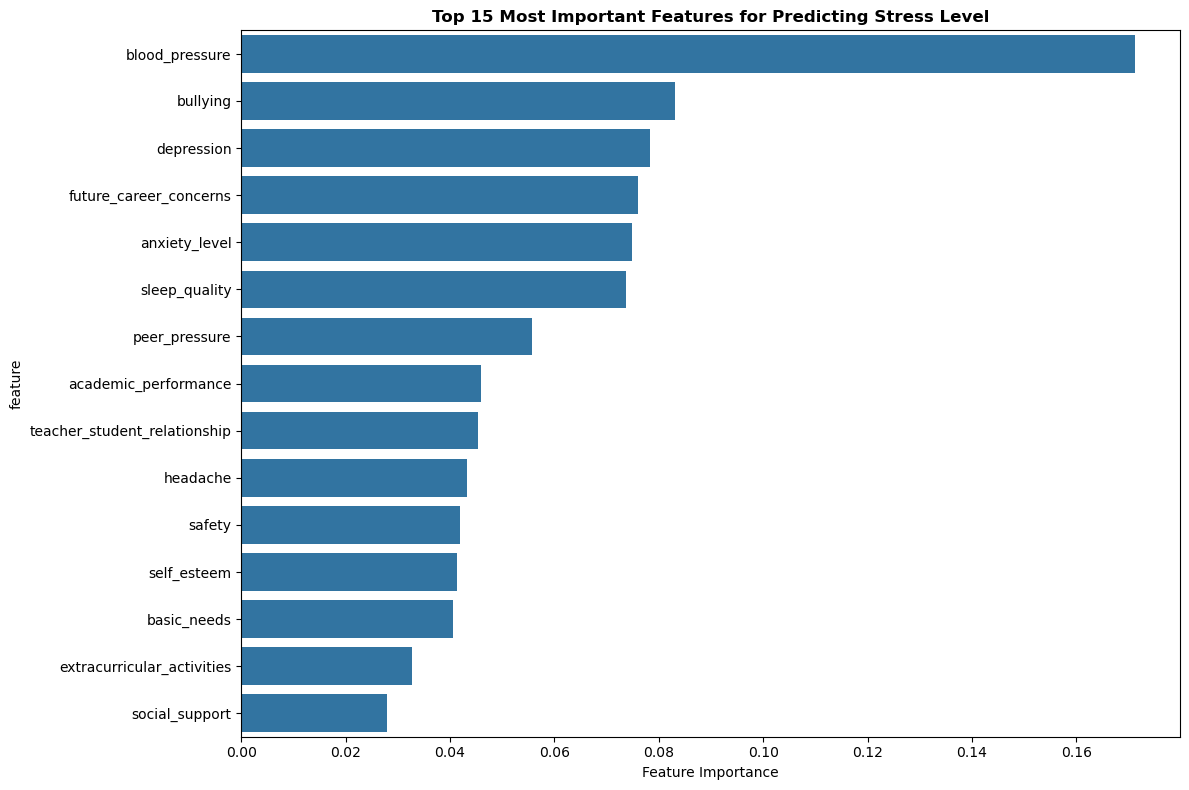

In [23]:
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), y='feature', x='importance')
plt.title('Top 15 Most Important Features for Predicting Stress Level', fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [24]:
print("Top 10 Most Important Features:")
for i, (feature, importance) in enumerate(feature_importance.head(10).values):
    print(f"{i+1}. {feature}: {importance:.3f}")

Top 10 Most Important Features:
1. blood_pressure: 0.171
2. bullying: 0.083
3. depression: 0.078
4. future_career_concerns: 0.076
5. anxiety_level: 0.075
6. sleep_quality: 0.074
7. peer_pressure: 0.056
8. academic_performance: 0.046
9. teacher_student_relationship: 0.045
10. headache: 0.043


In [25]:
print("\n🎯 KEY FINDINGS:")
print("1. Psychological factors (anxiety, depression, self-esteem) are the strongest predictors of stress")
print("2. Sleep quality has a significant inverse relationship with stress levels")
print("3. Academic performance and study load create a complex stress dynamic")
print("4. Social support acts as a protective factor against high stress")


🎯 KEY FINDINGS:
1. Psychological factors (anxiety, depression, self-esteem) are the strongest predictors of stress
2. Sleep quality has a significant inverse relationship with stress levels
3. Academic performance and study load create a complex stress dynamic
4. Social support acts as a protective factor against high stress


In [26]:
print("\n💡 RECOMMENDATIONS FOR STUDENTS:")
print("• Prioritize mental health: Seek counseling for anxiety and depression")
print("• Establish healthy sleep hygiene: Aim for 7-9 hours of quality sleep")
print("• Build strong social support networks: Join study groups and social activities")
print("• Practice stress management techniques: Meditation, exercise, time management")

print("\n🏫 RECOMMENDATIONS FOR INSTITUTIONS:")
print("• Implement comprehensive mental health programs")
print("• Provide academic support services to help manage study load")
print("• Create environments that promote social connection")
print("• Offer stress management workshops and resources")


💡 RECOMMENDATIONS FOR STUDENTS:
• Prioritize mental health: Seek counseling for anxiety and depression
• Establish healthy sleep hygiene: Aim for 7-9 hours of quality sleep
• Build strong social support networks: Join study groups and social activities
• Practice stress management techniques: Meditation, exercise, time management

🏫 RECOMMENDATIONS FOR INSTITUTIONS:
• Implement comprehensive mental health programs
• Provide academic support services to help manage study load
• Create environments that promote social connection
• Offer stress management workshops and resources


In [27]:
print("\n📊 MODEL PERFORMANCE SUMMARY:")
print(f"• Random Forest achieved {accuracy_score(y_test, rf_pred):.1%} accuracy")
print(f"• Model can effectively identify students at risk of high stress")
print(f"• Top predictive factors: {', '.join(feature_importance.head(3)['feature'].tolist())}")


📊 MODEL PERFORMANCE SUMMARY:
• Random Forest achieved 84.5% accuracy
• Model can effectively identify students at risk of high stress
• Top predictive factors: blood_pressure, bullying, depression
